### aim: compare assemblage at end-of run differences between model runs

### date: 

In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm

# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


In [3]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')

#cdo remapnn,targetgrid input.nc output.nc

#cdo remapnn,r360x180 /gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc /gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims_rg.nc

In [4]:
#kostelec - polsko
kostelec_6 = ['#C94B3C', '#E47A5C', '#A8B89C', '#6B9B7D', '#7FA4B8', '#4A3830']
kostelec_12 = ['#B23D32', '#C94B3C', '#E47A5C', '#D89B7A', '#E5C9A8', '#C8D4B8', '#A8B89C', '#6B9B7D', '#7FA4B8', '#5B7A8C', '#4A3830', '#2A1F1A']

#prachov - jezero 
prachovjezero_6 = ['#E85A2A', '#F4A63D', '#6B8C3E', '#5B9BAD', '#4A6B8A', '#6B3428']
prachovjezero_12 = ['#D84B28', '#E85A2A', '#F27435', '#F4A63D', '#D4B665', '#89A648', '#6B8C3E', '#4E7054', '#5B9BAD', '#4A6B8A', '#6B3428', '#3D2820']

# Tatry 
tatry_6 = ['#9B7850', '#D4C8A8', '#5B7F68', '#7BA6BC', '#A8BECF', '#3A4F3C']
tatry_12 = ['#7A5F40', '#9B7850', '#C4B090', '#E5D8B8', '#B8D090', '#8FAB80', '#5B7F68', '#5B7B7C', '#7BA6BC', '#A8BECF', '#3A4F3C', '#2B3A2E']
#cesky raj
ceskyraj_6 = ['#B8734E', '#D4A562', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#3A2F28']
ceskyraj_12 = ['#A85C3C', '#B8734E', '#D49558', '#D4A562', '#E5C485', '#9CB68A', '#6B8B72', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#5B3F4A', '#3A2F28']

## prachov - skaly
prachovskaly_6 = ['#B8844E', '#D4A865', '#6B8B5C', '#4B7B8C', '#2B5B8C', '#1B3F5C']
prachovskaly_12 = ['#9B6B3C', '#B8844E', '#C89B5A', '#D4A865', '#E5C68A', '#8BA872', '#6B8B5C', '#4B6B5A', '#5B8B9C', '#4B7B8C', '#2B5B8C', '#1B3F5C']

## jested lanovka
jested_6 = ['#D86B45', '#D4B870', '#8FAB7C', '#5B7B8C', '#6B8BAC', '#3A5B48']
jested_12 = ['#C85B3A', '#D86B45', '#E59B58', '#D4B870', '#E5D090', '#B8C88C', '#8FAB7C', '#6B8B78', '#5B7B8C', '#6B8BAC', '#4B6B5C', '#3A5B48']

## krkonose 
krkonose_6 = ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']
krkonose_12 = ['#B87A3C', '#E5A542', '#F5C855', '#D4DB6A', '#C4D858', '#A8C850', '#6B8B5C', '#5B7B6C', '#4B6B8C', '#7A9BAC', '#8B6B47', '#5B4B38']

## dumbier
dumbier_6 = ['#D87845', '#E5C8A0', '#4B7BC2', '#6B9BD8', '#7AB8E5', '#1A2B3A']
dumbier_12 = ['#C86838', '#D87845', '#E59B68', '#E5C8A0', '#F5E8D0', '#A8C8E5', '#7AB8E5', '#6B9BD8', '#4B7BC2', '#3A5B8C', '#2A3B5C', '#1A2B3A']

## assorted snippets

#### notebook footer

In [5]:
def add_notebook_footer(fig, notebook_name, path_y_position=0.02):
    """
    Add notebook path as footer to figure with automatic spacing.
    
    Parameters:
    -----------
    fig : matplotlib figure object
    notebook_name : str
        Name of the notebook file (e.g., 'AMOCts.ipynb')
    path_y_position : float
        Y position for the footer text (default 0.02 = 2% from bottom)
        
    usage 
    bottom_margin = add_notebook_footer(fig, 'AMOCts.ipynb')
    plt.tight_layout(rect=[0, bottom_margin, 1, 0.96])    
    """
    notebook_path = os.path.abspath(os.getcwd())
    full_notebook_path = os.path.join(notebook_path, notebook_name)
    fig.text(0.5, path_y_position, f'Notebook: {full_notebook_path}', ha='center', 
             fontsize=10, style='italic', color='gray')
    
    # Return the bottom margin needed for tight_layout
    return path_y_position + 0.05  # Add buffer above text

#### tylist

In [6]:
def make_yearlist(yrst, yrend, dtype, tr, baseDir):
    yrs = np.arange(yrst,yrend+1,1)
    ylist = []
    for i in range(0,len(yrs)):
        ty = f'{baseDir}/{tr}/ORCA2_1m_{yrs[i]}*{dtype}*.nc'
        t2 = glob.glob(ty)
        #print(t2)
        ylist.append(t2[0])
    return ylist

## 0: identify runs

In [7]:
BASE = 'TOM12_TJ_LA50'
HOS = 'TOM12_TJ_LAH3'
CCLIM = 'TOM12_TJ_LA50'

## 1: get a 10-year clim of relevant files for all 3 runs, also regrid

    in get_clim.py
    in regrid_clim.sh
    right now this is a 2-year clim, once get_clim done, use 

In [8]:
ex = False
if ex:
    w = xr.open_dataset('/gpfs/data/greenocean/software/runs/TOM12_TJ_LAH3/ORCA2_1m_20120101_20121231_diad_T.nc')
    bdir = '/gpfs/data/greenocean/software/runs/'

    #print(list(w.variables))

    #grid_T, diad_T, ptrc_T, LoP_T
    varty = ['grid_T', 'diad_T', 'ptrc_T', 'LoP_T']
    #varty = ['grid_T']
    mods = [BASE,HOS,CCLIM]
    #mods = [BASE]
    ys = 2010; ye = 2011
    for mod in mods:
        for tvar in varty:
            try:
                w = xr.open_mfdataset(make_yearlist(ys,ye,tvar,mod,bdir))
                w = w.groupby('time_counter.month').mean('time_counter')
                w = w.rename({'month': 'time'})
                w.to_netcdf(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_{tvar}.nc')
                print(f'YES {bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_{tvar}.nc')
            except:
                print(f'--no for {bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_{tvar}.nc')

## depth-integrate phyto, zoo, pp_spec
## regrid those depth_integrated things (in regrid_clim.sh)
## 

In [9]:
ex = False
if ex:
    bdir = '/gpfs/data/greenocean/software/runs/'
    #grid_T, diad_T, ptrc_T, LoP_T
    varty = ['diad_T', 'ptrc_T']
    #varty = ['grid_T']
    mods = [BASE,HOS]#,CCLIM
    #mods = [BASE]
    ys = 2010; ye = 2019
    for mod in mods:
        print(mod)
        tvars = ['PPT', 'PPT_DIA', 'PPT_MIX', 'PPT_COC', 'PPT_PIC', 'PPT_PHA', 'PPT_FIX']
        w = xr.open_dataset(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_diad_T.nc')
        nw = integrate_depth(w,tvars,mask)
        nw.to_netcdf(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_diad_T_int.nc')
        print(f'ORCA2_1m_clim_{ys}_{ye}_diad_T_int.nc')

        tvars = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'MAC', 'DIA', 'MIX', 'COC', 'PIC', 'PHA', 'FIX',]
        w = xr.open_dataset(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T.nc')
        nw = integrate_depth(w,tvars,mask)
        nw.to_netcdf(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_int.nc')    
        print(f'ORCA2_1m_clim_{ys}_{ye}_ptrc_T_int.nc')

        tvars = ['NO3', 'Si', 'PO4', 'Fer',]
        w = xr.open_dataset(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T.nc')
        nw = average_top_meters(w,tvars,100)
        nw.to_netcdf(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_100m.nc')    
        print(f'ORCA2_1m_clim_{ys}_{ye}_ptrc_T_100m.nc')

        tvars = ['LV_DIA','LV_MIX','LV_COC','LV_PIC', 'LV_PHA','LV_FIX',]
        w = xr.open_dataset(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_LoP_T.nc')
        nw = average_top_meters(w,tvars,100)
        nw.to_netcdf(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_LoP_T_100m.nc')  
        print(f'ORCA2_1m_clim_{ys}_{ye}_LoP_T_100m.nc')

## make a meshmask
    see cdo command 

In [10]:
ex = False
if ex:
    mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')

    w = xr.open_dataset(f'{bdir}/{mod}/ORCA2_1m_clim_{ys}_{ye}_ptrc_T_100m.nc')
    w['NO3_mn'] = w.NO3.mean(dim = 'time')

    w['NO3_mn'].values = mask['ATL'].values
    plt.pcolormesh(w['NO3_mn'])
    w = w.rename({'NO3_mn': 'ATL'})
    w.to_netcdf('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_ATL.nc')

    #cdo remapnn,r360x180 /gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_ATL.nc /gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_ATL_rg.nc
    

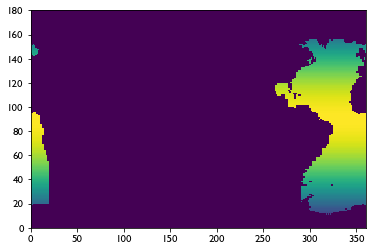

In [11]:
cdomask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/windAnalyis/wspdComponents/PlankTOMmask_regridrecalc.nc')
tmask = cdomask.tmask
ATL = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_ATL_rg.nc')
ATL = ATL.ATL
ATL_csize = tmask*ATL
plt.pcolormesh(tmask*ATL)

## load regridded and averaged data, 

In [12]:
bdir = '/gpfs/data/greenocean/software/runs/'
BASE = 'TOM12_TJ_LA50'
HOSE = 'TOM12_TJ_LAH3'  # Replace with actual HOSE designation

# Define file mappings
files = {
    'diad_int': 'ORCA2_1m_clim_2010_2019_diad_T_int_rg.nc',
    'ptrc_int': 'ORCA2_1m_clim_2010_2019_ptrc_T_int_rg.nc',
    'ptrc_100m': 'ORCA2_1m_clim_2010_2019_ptrc_T_100m_rg.nc',
    'LoP_100m': 'ORCA2_1m_clim_2010_2019_LoP_T_100m_rg.nc'
}

# Load BASE datasets
BASE_data = {}
for key, filename in files.items():
    filepath = os.path.join(bdir, BASE, filename)
    BASE_data[key] = xr.open_dataset(filepath)

# Load HOSE datasets
HOSE_data = {}
for key, filename in files.items():
    filepath = os.path.join(bdir, HOSE, filename)
    HOSE_data[key] = xr.open_dataset(filepath)

#  access like:
# BASE_data['ptrc_int']
# HOSE_data['diad_int']

#### biomass and ppint differences

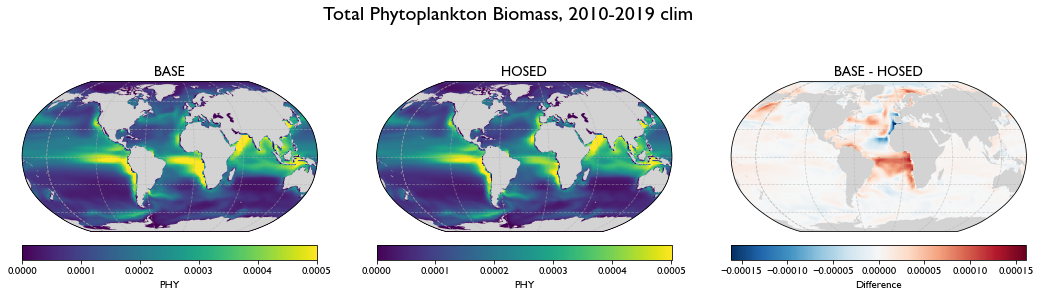

In [13]:
stit = 'Total Phytoplankton Biomass, 2010-2019 clim'
BASE_ds = BASE_data['ptrc_int']
HOSE_ds = HOSE_data['ptrc_int']

# Create PHY variable for both datasets
BASE_ds['PHY'] = (BASE_ds['DIA'] + BASE_ds['MIX'] + BASE_ds['COC'] + 
                  BASE_ds['PHA'] + BASE_ds['FIX'] + BASE_ds['PIC'])
HOSE_ds['PHY'] = (HOSE_ds['DIA'] + HOSE_ds['MIX'] + HOSE_ds['COC'] + 
                  HOSE_ds['PHA'] + HOSE_ds['FIX'] + HOSE_ds['PIC'])

# Average along time dimension
BASE_mean = BASE_ds['PHY'].mean(dim='time')
HOSE_mean = HOSE_ds['PHY'].mean(dim='time')
DIFF_mean = BASE_mean - HOSE_mean

# Set colormap limits for BASE and HOSED plots
vmin = 0  # Adjust these as needed
vmax = BASE_mean.quantile(0.99).values  # Or set a specific value

# Create figure with 3 subplots
fig = plt.figure(figsize=(18, 5))

# Use Robinson projection centered on Atlantic (0°E)
projection = ccrs.Robinson(central_longitude=-30)

# Plot 1: BASE
ax1 = fig.add_subplot(131, projection=projection)
ax1.coastlines()
ax1.add_feature(cfeature.LAND, facecolor='lightgray')
ax1.gridlines(draw_labels=False, linestyle='--', alpha=0.5)
im1 = BASE_mean.plot(ax=ax1, transform=ccrs.PlateCarree(), 
                     cmap='viridis', add_colorbar=False,
                     vmin=vmin, vmax=vmax)
ax1.set_title('BASE', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, label='PHY')

# Plot 2: HOSED
ax2 = fig.add_subplot(132, projection=projection)
ax2.coastlines()
ax2.add_feature(cfeature.LAND, facecolor='lightgray')
ax2.gridlines(draw_labels=False, linestyle='--', alpha=0.5)
im2 = HOSE_mean.plot(ax=ax2, transform=ccrs.PlateCarree(), 
                     cmap='viridis', add_colorbar=False,
                     vmin=vmin, vmax=vmax)
ax2.set_title('HOSED', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, label='PHY')

# Plot 3: DIFFERENCE (BASE - HOSED)
ax3 = fig.add_subplot(133, projection=projection)
ax3.coastlines()
ax3.add_feature(cfeature.LAND, facecolor='lightgray')
ax3.gridlines(draw_labels=False, linestyle='--', alpha=0.5)
im3 = DIFF_mean.plot(ax=ax3, transform=ccrs.PlateCarree(), 
                     cmap='RdBu_r', add_colorbar=False, center=0)
ax3.set_title('BASE - HOSED', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, label='Difference')


ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
ax3.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)


plt.tight_layout()
plt.suptitle(stit, y = 0.9, fontsize = 20)
plt.savefig('./plts/phy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


#### phytoplankton productivity

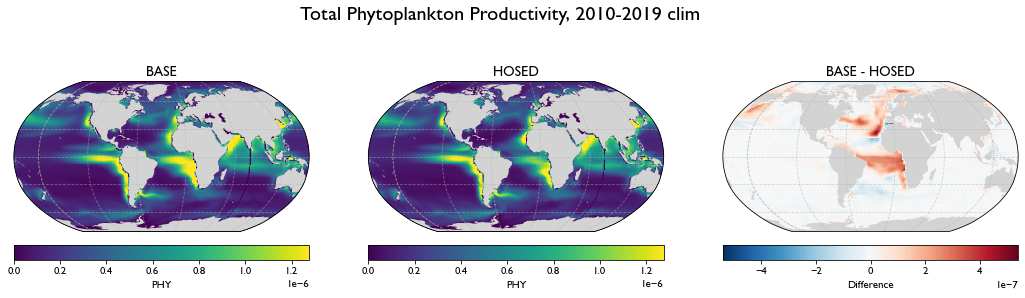

In [14]:
stit = 'Total Phytoplankton Productivity, 2010-2019 clim'
BASE_ds = BASE_data['diad_int']
HOSE_ds = HOSE_data['diad_int']

# Create PHY variable for both datasets
BASE_ds['PHY'] = (BASE_ds['PPT_DIA'] + BASE_ds['PPT_MIX'] + BASE_ds['PPT_COC'] + 
                  BASE_ds['PPT_PHA'] + BASE_ds['PPT_FIX'] + BASE_ds['PPT_PIC'])
HOSE_ds['PHY'] = (HOSE_ds['PPT_DIA'] + HOSE_ds['PPT_MIX'] + HOSE_ds['PPT_COC'] + 
                  HOSE_ds['PPT_PHA'] + HOSE_ds['PPT_FIX'] + HOSE_ds['PPT_PIC'])

# Average along time dimension
BASE_mean = BASE_ds['PHY'].mean(dim='time')
HOSE_mean = HOSE_ds['PHY'].mean(dim='time')
DIFF_mean = BASE_mean - HOSE_mean

# Set colormap limits for BASE and HOSED plots
vmin = 0  # Adjust these as needed
vmax = BASE_mean.quantile(0.99).values  # Or set a specific value

# Create figure with 3 subplots
fig = plt.figure(figsize=(18, 5))

# Use Robinson projection centered on Atlantic (0°E)
projection = ccrs.Robinson(central_longitude=-30)

# Plot 1: BASE
ax1 = fig.add_subplot(131, projection=projection)
ax1.coastlines()
ax1.add_feature(cfeature.LAND, facecolor='lightgray')
ax1.gridlines(draw_labels=False, linestyle='--', alpha=0.5)
im1 = BASE_mean.plot(ax=ax1, transform=ccrs.PlateCarree(), 
                     cmap='viridis', add_colorbar=False,
                     vmin=vmin, vmax=vmax)
ax1.set_title('BASE', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, label='PHY')

# Plot 2: HOSED
ax2 = fig.add_subplot(132, projection=projection)
ax2.coastlines()
ax2.add_feature(cfeature.LAND, facecolor='lightgray')
ax2.gridlines(draw_labels=False, linestyle='--', alpha=0.5)
im2 = HOSE_mean.plot(ax=ax2, transform=ccrs.PlateCarree(), 
                     cmap='viridis', add_colorbar=False,
                     vmin=vmin, vmax=vmax)
ax2.set_title('HOSED', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, label='PHY')

# Plot 3: DIFFERENCE (BASE - HOSED)
ax3 = fig.add_subplot(133, projection=projection)
ax3.coastlines()
ax3.add_feature(cfeature.LAND, facecolor='lightgray')
ax3.gridlines(draw_labels=False, linestyle='--', alpha=0.5)
im3 = DIFF_mean.plot(ax=ax3, transform=ccrs.PlateCarree(), 
                     cmap='RdBu_r', add_colorbar=False, center=0)
ax3.set_title('BASE - HOSED', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, label='Difference')


ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
ax3.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)


plt.tight_layout()
plt.suptitle(stit, y = 0.9, fontsize = 20)
plt.savefig('./plts/ppt_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


#### Heterotroph biomass

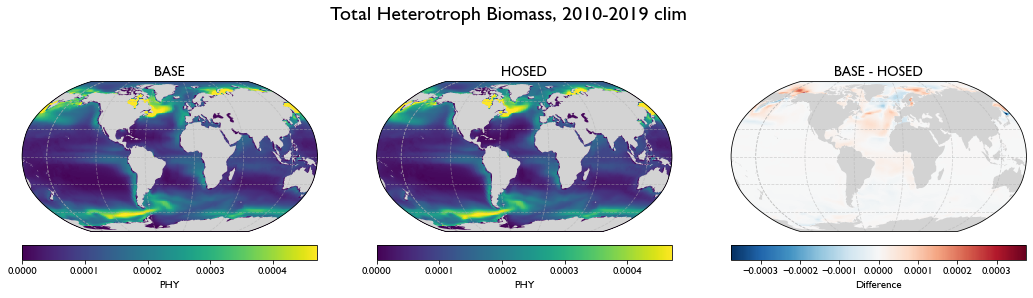

In [15]:
stit = 'Total Heterotroph Biomass, 2010-2019 clim'
BASE_ds = BASE_data['ptrc_int']
HOSE_ds = HOSE_data['ptrc_int']

# Create PHY variable for both datasets
BASE_ds['ZOO'] = (BASE_ds['BAC'] + BASE_ds['PRO'] + BASE_ds['PTE'] + 
                  BASE_ds['MES'] + BASE_ds['GEL'] + BASE_ds['MAC'])
HOSE_ds['ZOO'] = (HOSE_ds['BAC'] + HOSE_ds['PRO'] + HOSE_ds['PTE'] + 
                  HOSE_ds['MES'] + HOSE_ds['GEL'] + HOSE_ds['MAC'])

# Average along time dimension
BASE_mean = BASE_ds['ZOO'].mean(dim='time')
HOSE_mean = HOSE_ds['ZOO'].mean(dim='time')
DIFF_mean = BASE_mean - HOSE_mean

# Set colormap limits for BASE and HOSED plots
vmin = 0  # Adjust these as needed
vmax = BASE_mean.quantile(0.99).values  # Or set a specific value

# Create figure with 3 subplots
fig = plt.figure(figsize=(18, 5))

# Use Robinson projection centered on Atlantic (0°E)
projection = ccrs.Robinson(central_longitude=-30)

# Plot 1: BASE
ax1 = fig.add_subplot(131, projection=projection)
ax1.coastlines()
ax1.add_feature(cfeature.LAND, facecolor='lightgray')
ax1.gridlines(draw_labels=False, linestyle='--', alpha=0.5)
im1 = BASE_mean.plot(ax=ax1, transform=ccrs.PlateCarree(), 
                     cmap='viridis', add_colorbar=False,
                     vmin=vmin, vmax=vmax)
ax1.set_title('BASE', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, label='PHY')

# Plot 2: HOSED
ax2 = fig.add_subplot(132, projection=projection)
ax2.coastlines()
ax2.add_feature(cfeature.LAND, facecolor='lightgray')
ax2.gridlines(draw_labels=False, linestyle='--', alpha=0.5)
im2 = HOSE_mean.plot(ax=ax2, transform=ccrs.PlateCarree(), 
                     cmap='viridis', add_colorbar=False,
                     vmin=vmin, vmax=vmax)
ax2.set_title('HOSED', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, label='PHY')

# Plot 3: DIFFERENCE (BASE - HOSED)
ax3 = fig.add_subplot(133, projection=projection)
ax3.coastlines()
ax3.add_feature(cfeature.LAND, facecolor='lightgray')
ax3.gridlines(draw_labels=False, linestyle='--', alpha=0.5)
im3 = DIFF_mean.plot(ax=ax3, transform=ccrs.PlateCarree(), 
                     cmap='RdBu_r', add_colorbar=False, center=0)
ax3.set_title('BASE - HOSED', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, label='Difference')


ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)
ax3.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none', zorder=2)


plt.tight_layout()
plt.suptitle(stit, y = 0.9, fontsize = 20)
plt.savefig('./plts/zoo_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## calculate latitudinal means

In [16]:
BASE_ds = BASE_data['ptrc_int']
HOSE_ds = HOSE_data['ptrc_int']

variables = ['DIA', 'MIX', 'COC', 'PHA', 'FIX', 'PIC',]
BASE_phy_lat = compute_latitudinal_profiles(BASE_ds, variables, ATL_csize)
HOSE_phy_lat = compute_latitudinal_profiles(HOSE_ds, variables, ATL_csize)


variables = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'MAC',]
BASE_zoo_lat = compute_latitudinal_profiles(BASE_ds, variables, ATL_csize)
HOSE_zoo_lat = compute_latitudinal_profiles(HOSE_ds, variables, ATL_csize)


BASE_ds = BASE_data['diad_int']
HOSE_ds = HOSE_data['diad_int']
variables = ['PPT_DIA', 'PPT_MIX', 'PPT_COC', 'PPT_PHA', 'PPT_FIX', 'PPT_PIC',]

BASE_ppt_lat = compute_latitudinal_profiles(BASE_ds, variables, ATL_csize)
HOSE_ppt_lat = compute_latitudinal_profiles(HOSE_ds, variables, ATL_csize)

BASE_ds = BASE_data['diad_int']
HOSE_ds = HOSE_data['diad_int']
variables = ['PPT_DIA', 'PPT_MIX', 'PPT_COC', 'PPT_PHA', 'PPT_FIX', 'PPT_PIC',]

BASE_ppt_lat = compute_latitudinal_profiles(BASE_ds, variables, ATL_csize)
HOSE_ppt_lat = compute_latitudinal_profiles(HOSE_ds, variables, ATL_csize)

BASE_ds = BASE_data['LoP_100m']
HOSE_ds = HOSE_data['LoP_100m']

variables = ['LV_DIA', 'LV_MIX', 'LV_COC', 'LV_PHA', 'LV_FIX', 'LV_PIC',]
BASE_lim_lat = compute_latitudinal_profiles(BASE_ds, variables, ATL_csize)
HOSE_lim_lat = compute_latitudinal_profiles(HOSE_ds, variables, ATL_csize)

BASE_ds = BASE_data['ptrc_100m']
HOSE_ds = HOSE_data['ptrc_100m']
list(BASE_ds.variables)
variables = ['NO3', 'Si', 'PO4', 'Fer',]
BASE_nut_lat = compute_latitudinal_profiles(BASE_ds, variables, ATL_csize)
HOSE_nut_lat = compute_latitudinal_profiles(HOSE_ds, variables, ATL_csize)

NameError: name 'compute_latitudinal_profiles' is not defined

#### phyto by-latitude plot

In [ ]:
D1 = BASE_phy_lat
D2 = HOSE_phy_lat
stit = 'autotroph biomass by functional group, 2010-2019 climatology'
# Settable colors list
colors = ['b', 'r', '#45B7D1', 'rosybrown', 'k', '#F7DC6F']

# Variable names
variable_names = ['DIA', 'MIX', 'COC', 'PHA', 'FIX', 'PIC']
#variable_names = ['PIC']
# Create figure with 1 row, 3 columns
fact = 0.8
fig, axes = plt.subplots(1, 3, figsize=(18*fact, 8*fact), sharey=True)

# Get latitude values
lat = BASE_phy_lat['lat'].values

# Function to plot stacked data with proper handling of negative values

# Plot 1: BASE_phy_lat
plot_stacked(axes[0], D1, lat, variable_names, colors, 'BASE')

# Plot 2: HOSE_phy_lat
plot_stacked(axes[1], D2, lat, variable_names, colors, 'HOSE')

# Plot 3: Difference (BASE - HOSE)
DIFF = D1 - D2
plot_stacked(axes[2], DIFF, lat, variable_names, colors, 'BASE - HOSE')

# Set y-axis label only for leftmost plot
axes[0].set_ylabel('Latitude', fontsize=12)

for ax in axes:
    ax.set_ylim(-80,67)
axes[0].set_xlim([0,0.0005])
axes[1].set_xlim([0,0.0005])
fig.suptitle(stit, fontsize = 20)
plt.tight_layout()
plt.savefig('./plts/PHY_stacked_latitude_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot created successfully!")

#### ppt by-latitude plot

In [ ]:
D1 = BASE_ppt_lat
D2 = HOSE_ppt_lat
stit = 'autotroph primary productivity by functional group, 2010-2019 climatology'
# Settable colors list
colors = ['b', 'r', '#45B7D1', 'rosybrown', 'k', '#F7DC6F']

# Variable names
variable_names = ['PPT_DIA', 'PPT_MIX', 'PPT_COC', 'PPT_PHA', 'PPT_FIX', 'PPT_PIC']
variable_names = ['PPT_PIC']
# Create figure with 1 row, 3 columns
fact = 0.8
fig, axes = plt.subplots(1, 3, figsize=(18*fact, 8*fact), sharey=True)

# Get latitude values
lat = BASE_phy_lat['lat'].values

# Function to plot stacked data with proper handling of negative values

# Plot 1: BASE_phy_lat
plot_stacked(axes[0], D1, lat, variable_names, colors, 'BASE')

# Plot 2: HOSE_phy_lat
plot_stacked(axes[1], D2, lat, variable_names, colors, 'HOSE')

# Plot 3: Difference (BASE - HOSE)
DIFF = D1 - D2
plot_stacked(axes[2], DIFF, lat, variable_names, colors, 'BASE - HOSE')

# Set y-axis label only for leftmost plot
axes[0].set_ylabel('Latitude', fontsize=12)

for ax in axes:
    ax.set_ylim(-80,67)
axes[0].set_xlim([0,1.2e-6])
axes[1].set_xlim([0,1.2e-6])
fig.suptitle(stit, fontsize = 20)
plt.tight_layout()
plt.savefig('./plts/PPT_stacked_latitude_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot created successfully!")

#### zooplankton by-latitude plot

In [ ]:
D1 = BASE_zoo_lat
D2 = HOSE_zoo_lat
stit = 'autotroph primary productivity by functional group, 2010-2019 climatology'
# Settable colors list
colors = krkonose_6 #['b', 'r', '#45B7D1', 'rosybrown', 'k', '#F7DC6F']

# Variable names
variable_names = ['PPT_DIA', 'PPT_MIX', 'PPT_COC', 'PPT_PHA', 'PPT_FIX', 'PPT_PIC']
variable_names = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'MAC',]

# Create figure with 1 row, 3 columns
fact = 0.8
fig, axes = plt.subplots(1, 3, figsize=(18*fact, 8*fact), sharey=True)

# Get latitude values
lat = BASE_phy_lat['lat'].values

# Function to plot stacked data with proper handling of negative values

# Plot 1: BASE_phy_lat
plot_stacked(axes[0], D1, lat, variable_names, colors, 'BASE')

# Plot 2: HOSE_phy_lat
plot_stacked(axes[1], D2, lat, variable_names, colors, 'HOSE')

# Plot 3: Difference (BASE - HOSE)
DIFF = D1 - D2
plot_stacked(axes[2], DIFF, lat, variable_names, colors, 'BASE - HOSE')

# Set y-axis label only for leftmost plot
axes[0].set_ylabel('Latitude', fontsize=12)

for ax in axes:
    ax.set_ylim(-80,67)
axes[0].set_xlim([0,3.9e-4])
axes[1].set_xlim([0,3.9e-4])
fig.suptitle(stit, fontsize = 20)
plt.tight_layout()
plt.savefig('./plts/ZOO_stacked_latitude_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot created successfully!")

#### nutrient limitation

In [ ]:
D1 = BASE_lim_lat
D2 = HOSE_lim_lat
stit = 'autotroph primary productivity by functional group, 2010-2019 climatology'
# Settable colors list
colors = krkonose_6 #['b', 'r', '#45B7D1', 'rosybrown', 'k', '#F7DC6F']
colors = ['b', 'r', '#45B7D1', 'rosybrown', 'k', '#F7DC6F']

# Variable names
variable_names = ['LV_DIA', 'LV_MIX', 'LV_COC', 'LV_PHA', 'LV_FIX', 'LV_PIC']
#variable_names = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'MAC',]

# Create figure with 1 row, 3 columns
fact = 0.8
fig, axes = plt.subplots(1, 3, figsize=(18*fact, 8*fact), sharey=True)

# Get latitude values
lat = BASE_phy_lat['lat'].values

# Function to plot stacked data with proper handling of negative values

# Plot 1: BASE_phy_lat
plot_point(axes[0], D1, lat, variable_names, colors, 'BASE')

# Plot 2: HOSE_phy_lat
plot_point(axes[1], D2, lat, variable_names, colors, 'HOSE')

# Plot 3: Difference (BASE - HOSE)
DIFF = D1 - D2
plot_point(axes[2], DIFF, lat, variable_names, colors, 'BASE - HOSE')

# Set y-axis label only for leftmost plot
axes[0].set_ylabel('Latitude', fontsize=12)

for ax in axes:
    ax.set_ylim(-80,67)
# axes[0].set_xlim([0,3.9e-4])
# axes[1].set_xlim([0,3.9e-4])
fig.suptitle(stit, fontsize = 20)
plt.tight_layout()
plt.savefig('./plts/LoP_stacked_latitude_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot created successfully!")

In [ ]:
D1 = BASE_nut_lat
D2 = HOSE_nut_lat
stit = 'nutrient availability, 2010-2019 climatology'
# Settable colors list
colors = krkonose_6 #['b', 'r', '#45B7D1', 'rosybrown', 'k', '#F7DC6F']
colors = ['b', 'r', '#45B7D1', 'rosybrown', 'k', '#F7DC6F']

# Variable names
variable_names1 = ['Fer','Si','NO3','PO4']
#variable_names = ['BAC', 'PRO', 'PTE', 'MES', 'GEL', 'MAC',]

for i in range(0,4):
    
    variable_names = ['foo']
    variable_names[0] = (variable_names1[i])
    stit = f'nutrients, {variable_names1[i]}'

    # Create figure with 1 row, 3 columns
    fact = 0.4
    fig, axes = plt.subplots(1, 3, figsize=(18*fact, 8*fact), sharey=True)

    # Get latitude values
    lat = BASE_phy_lat['lat'].values

    # Function to plot stacked data with proper handling of negative values

    # Plot 1: BASE_phy_lat
    plot_stacked(axes[0], D1, lat, variable_names, colors, 'BASE')

    # Plot 2: HOSE_phy_lat
    plot_stacked(axes[1], D2, lat, variable_names, colors, 'HOSE')

    # Plot 3: Difference (BASE - HOSE)
    DIFF = D1 - D2
    plot_stacked(axes[2], DIFF, lat, variable_names, colors, 'BASE - HOSE')

    # Set y-axis label only for leftmost plot
    axes[0].set_ylabel('Latitude', fontsize=12)

    for ax in axes:
        ax.set_ylim(-80,67)
    # axes[0].set_xlim([0,3.9e-4])
    # axes[1].set_xlim([0,3.9e-4])
    fig.suptitle(stit, fontsize = 20)
    plt.tight_layout()
    #plt.savefig('./plts/LoP_stacked_latitude_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Plot created successfully!")

## maximum growth rate
    
    - see LimitsOfPhytoplankton/whoContributesToPP.ipynb

In [ ]:
def get_tgfunc(tsn,pft, verbose = False):

    ## these come from namelist.trc.sms 
    rn_mutpft =     np.array([15.20   ,  16.70  ,    3.00  , 28.40  ,  26.60  ,  16.90  ,\
                              24.60  ,  24.20  ,  20.30  ,  27.70  ,  15.00  ,  27.80  ,])
    rn_mudpft =     np.array([30.5    ,  14.1   ,   25.05  , 22.7   ,  24.6   ,  15.8   , \
                              26.1   ,  16.9   ,   10.7  ,  23.2   ,  20.0   ,  8.0    ,])
    
    pftv = ['dia','mix','coc','pic','pha','fix']
    index_of_pft= pftv.index(pft)
    
    tgfunc = np.exp(-1.*(tsn-rn_mutpft[index_of_pft])**2./rn_mudpft[index_of_pft]**2.)

    
    if pft == 'coc':
        ztemp = 10.
        ztmax = (1./5. + 4./5.*max(tsn,-1.8)/(ztemp))*tgfunc
        tgfunc = min(ztmax,tgfunc)
        
    if verbose:
        print(tgfunc)
        
    return tgfunc
        
get_tgfunc(8,'coc',True)

In [ ]:
pftv = ['dia','mix','pic','pha','fix']

tsn = np.arange(-2,40,0.25)
print(len(tsn))
funcs = np.zeros([5,len(tsn)])

for i in range(0,5):
    funcs[i,:] = get_tgfunc(tsn,pftv[i])

tsn = np.arange(-2,40,0.25)
cocs = np.copy(tsn)

for i in range(0,len(tsn)):
    cocs[i] = get_tgfunc(tsn[i],'coc')
plt.figure()
for i in range(0,5):
    plt.plot(tsn, funcs[i,:], label = pftv[i])
plt.plot(tsn, cocs[:], label = 'coc')
    
plt.legend(bbox_to_anchor = [1,1])
plt.title('tgfunc in this run by pft')
plt.xlabel('deg C')

## Bray-Curtis Dissimilarity

In [ ]:
BASE_ds = BASE_data['ptrc_int']
HOSE_ds = HOSE_data['ptrc_int']

In [ ]:
BASE_ds_mn = BASE_ds.mean(dim = 'time')
HOSE_ds_mn = HOSE_ds.mean(dim = 'time')

zoo = ['BAC','PRO','PTE','MES','GEL','MAC',]
phy = [ 'DIA','MIX','COC','PIC','PHA','FIX',]


bc_phy = bray_curtis_dissimilarity(BASE_ds_mn, HOSE_ds_mn, phy)
bc_zoo = bray_curtis_dissimilarity(BASE_ds_mn, HOSE_ds_mn, zoo)

In [ ]:
bc_phy

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_global_maps(xr1, xr2, titles=['Dataset 1', 'Dataset 2'], cmap='viridis'):
    """
    Plot two 2D xarrays as global maps using Cartopy.
    
    Parameters:
    -----------
    xr1, xr2 : xarray.DataArray
        Two 2D xarray DataArrays to plot
    titles : list
        Titles for each subplot
    cmap : str
        Colormap name
    """
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), 
                             subplot_kw={'projection': ccrs.PlateCarree()})
    
    for i, (data, title) in enumerate(zip([xr1, xr2], titles)):
        ax = axes[i]
        
        # Plot the data
        im = data.plot(ax=ax, transform=ccrs.PlateCarree(), 
                       cmap=cmap, add_colorbar=True,
                       cbar_kwargs={'shrink': 0.8})
        
        # Add coastlines and features
        ax.coastlines()
        ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=1, zorder = 2)
        ax.gridlines(draw_labels=True, alpha=0.5)
        
        ax.set_title(title, fontsize=14)
    
    add_notebook_footer(fig,'AMOC-PLANKTOM/AMOC-LoP-202510/clim-assemblage-bray-curtis.ipynb')
    plt.tight_layout()
    
    plt.savefig('./plts/bray_curtis.jpg')
    plt.show()

# Example usage:
plot_global_maps(bc_phy,\
                 bc_zoo,\
                 titles=['bc_phy', 'bc_zoo'])

# helper functions

### integrate by depth integrate_depth(dataset, var_list, tmesh, suffix='_int')

In [ ]:
def integrate_depth(dataset, var_list, tmesh, suffix='_int'):
    """
    Integrate 4D variables along depth dimension to create 3D variables.
    
    Parameters
    ----------
    dataset : xr.Dataset
        Input dataset with 4D variables (time, depth, y, x)
    var_list : list of str
        Names of variables to integrate
    tmesh : xr.Dataset
        Meshmask dataset containing cell thickness (e3t_0)
    suffix : str, optional
        Suffix to append to integrated variable names (default: '_int')
        Note: This parameter is kept for backwards compatibility but is not used
        
    Returns
    -------
    xr.Dataset
        Dataset containing only integrated versions of variables from var_list
    """
    
    # Find the time dimension name
    time_dim = None
    for var in var_list:
        if var in dataset.data_vars:
            dims = dataset[var].dims
            # Assume first dimension is time
            time_dim = dims[0]
            break
    
    if time_dim is None:
        raise ValueError(f"Could not find time dimension in variables: {var_list}")
    
    # Find the depth dimension name (typically 'deptht', 'depth', 'z', etc.)
    depth_dim = None
    for var in var_list:
        if var in dataset.data_vars:
            dims = dataset[var].dims
            if len(dims) >= 2:  # Should be 4D
                depth_dim = dims[1]
            break
    
    if depth_dim is None:
        raise ValueError(f"Could not find depth dimension in variables: {var_list}")
    
    # Get cell thickness (e3t) and rename dimensions to match dataset
    e3t = tmesh['e3t_0'].copy()
    
    # Rename tmesh dimensions to match dataset dimensions
    dim_mapping = {}
    if 't' in e3t.dims:
        dim_mapping['t'] = time_dim
    if 'z' in e3t.dims:
        dim_mapping['z'] = depth_dim
    
    if dim_mapping:
        e3t = e3t.rename(dim_mapping)
    
    # Handle time dimension: squeeze if singleton, then broadcast if needed
    if time_dim in e3t.dims and e3t.sizes[time_dim] == 1:
        e3t = e3t.squeeze(time_dim, drop=True)
    
    # If e3t doesn't have the dataset's time dimension, add it
    if time_dim not in e3t.dims and time_dim in dataset.dims:
        e3t = e3t.expand_dims({time_dim: dataset[time_dim]})
    
    # Create empty output dataset
    output_ds = xr.Dataset()
    
    # Integrate each variable
    for var in var_list:
        if var not in dataset.data_vars:
            print(f"Warning: variable {var} not found in dataset")
            continue
        
        # Broadcast e3t to match variable dimensions
        e3t_broadcasted = xr.broadcast(dataset[var], e3t)[1]
        
        # Depth-integrated values
        integrated = (dataset[var] * e3t_broadcasted).sum(dim=depth_dim)
        
        # Add to output dataset without suffix
        output_ds[var] = integrated
    
    return output_ds

### top x meter avg: average_top_meters(dataset, var_list, depth_meters):

In [ ]:
def average_top_meters(dataset, var_list, depth_meters):
    """
    Average 4D variables over the top x meters to create 3D variables.
    
    Parameters
    ----------
    dataset : xr.Dataset
        Input dataset with 4D variables (time, depth, y, x)
    var_list : list of str
        Names of variables to average
    depth_meters : int or float
        Depth in meters over which to average (e.g., 100 for top 100m)
        
    Returns
    -------
    xr.Dataset
        Dataset containing only averaged versions of variables from var_list
    """
    
    # Load meshmask
    tmesh = xr.open_dataset('/gpfs/data/greenocean/software/resources/regrid/mesh_mask3_6.nc')
    
    # Find the time dimension name
    time_dim = None
    for var in var_list:
        if var in dataset.data_vars:
            dims = dataset[var].dims
            time_dim = dims[0]
            break
    
    if time_dim is None:
        raise ValueError(f"Could not find time dimension in variables: {var_list}")
    
    # Find the depth dimension name
    depth_dim = None
    for var in var_list:
        if var in dataset.data_vars:
            dims = dataset[var].dims
            if len(dims) >= 2:  # Should be 4D
                depth_dim = dims[1]
            break
    
    if depth_dim is None:
        raise ValueError(f"Could not find depth dimension in variables: {var_list}")
    
    # Get depth coordinates and cell thickness
    depths = dataset[depth_dim].values
    e3t = tmesh['e3t_0'].copy()
    
    # Rename tmesh dimensions to match dataset dimensions
    dim_mapping = {}
    if 't' in e3t.dims:
        dim_mapping['t'] = time_dim
    if 'z' in e3t.dims:
        dim_mapping['z'] = depth_dim
    
    if dim_mapping:
        e3t = e3t.rename(dim_mapping)
    
    # Handle time dimension: squeeze if singleton, then broadcast if needed
    if time_dim in e3t.dims and e3t.sizes[time_dim] == 1:
        e3t = e3t.squeeze(time_dim, drop=True)
    
    # If e3t doesn't have the dataset's time dimension, add it
    if time_dim not in e3t.dims and time_dim in dataset.dims:
        e3t = e3t.expand_dims({time_dim: dataset[time_dim]})
    
    # Find indices where depth <= depth_meters
    depth_mask = depths <= depth_meters
    depth_indices = [i for i, mask in enumerate(depth_mask) if mask]
    
    if not depth_indices:
        raise ValueError(f"No depths found <= {depth_meters} meters")
    
    # Create empty output dataset
    output_ds = xr.Dataset()
    
    # Average each variable over the selected depth range
    for var in var_list:
        if var not in dataset.data_vars:
            print(f"Warning: variable {var} not found in dataset")
            continue
        
        # Select data within the depth range
        var_subset = dataset[var].isel({depth_dim: depth_indices})
        e3t_subset = e3t.isel({depth_dim: depth_indices})
        
        # Broadcast e3t to match variable dimensions
        e3t_broadcasted = xr.broadcast(var_subset, e3t_subset)[1]
        
        # Depth-weighted average
        weighted_sum = (var_subset * e3t_broadcasted).sum(dim=depth_dim)
        total_thickness = e3t_broadcasted.sum(dim=depth_dim)
        averaged = weighted_sum / total_thickness
        
        # Add to output dataset without suffix
        output_ds[var] = averaged
    
    return output_ds

## latitudinal profiles

In [ ]:
def compute_latitudinal_profiles(ds, variables, mask, lon_dim='lon', time_dim='time'):
    """
    Compute latitudinal profiles for given variables.
    
    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset containing the variables
    variables : list of str
        List of variable names to compute profiles for
    mask : xarray.DataArray
        Spatial mask for weighted averaging (e.g., ATL_csize)
    lon_dim : str, optional
        Name of longitude dimension (default: 'lon')
    time_dim : str, optional
        Name of time dimension (default: 'time')
    
    Returns
    -------
    xarray.Dataset
        Dataset with latitudinal profiles for each variable
    """
    lat_profiles = {}
    
    for var in variables:
        # Average over time
        time_avg = ds[var].mean(time_dim)
        
        # Average over longitudes at each latitude, weighted by mask
        lat_profile = (time_avg * mask).sum(lon_dim) / mask.sum(lon_dim)
        
        # Store in dictionary
        lat_profiles[var] = lat_profile
    
    # Combine into dataset
    return xr.Dataset(lat_profiles)



## vertical stacking code

In [ ]:
def plot_stacked(ax, DS, lat, variable_names, colors, title):
    cumulative_pos = np.zeros(len(lat))  # For positive values (stack right)
    cumulative_neg = np.zeros(len(lat))  # For negative values (stack left)
    
    for i, var in enumerate(variable_names):
        var_data = DS[var].values
        
        # Create masks for where values are positive vs negative
        pos_mask = var_data > 0
        neg_mask = var_data < 0
        
        has_pos = np.any(pos_mask)
        has_neg = np.any(neg_mask)
        
        # For positive values: stack to the right
        if has_pos:
            # Start from cumulative_pos, add var_data only where positive
            left_edge_pos = cumulative_pos.copy()
            right_edge_pos = cumulative_pos.copy()
            right_edge_pos[pos_mask] = cumulative_pos[pos_mask] + var_data[pos_mask]
            
            ax.fill_betweenx(
                lat, 
                left_edge_pos, 
                right_edge_pos,
                color=colors[i],
                alpha=0.7,
                label=var
            )
            # Update cumulative only where values were positive
            cumulative_pos[pos_mask] += var_data[pos_mask]
        
        # For negative values: stack to the left
        if has_neg:
            # Start from cumulative_neg, add var_data only where negative
            left_edge_neg = cumulative_neg.copy()
            right_edge_neg = cumulative_neg.copy()
            right_edge_neg[neg_mask] = cumulative_neg[neg_mask] + var_data[neg_mask]
            
            ax.fill_betweenx(
                lat, 
                left_edge_neg, 
                right_edge_neg,
                color=colors[i],
                alpha=0.7,
                label=None if has_pos else var  # Only label if not already labeled
            )
            # Update cumulative only where values were negative
            cumulative_neg[neg_mask] += var_data[neg_mask]
    
    ax.set_xlabel('Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', frameon=True, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

In [ ]:
def plot_point(ax, DS, lat, variable_names, colors, title):
    for i, var in enumerate(variable_names):
        var_data = DS[var].values
        
        # Plot points for all values (positive and negative)
        ax.plot(
            var_data,
            lat,
            'o',  # circle marker
            color=colors[i],
            alpha=0.7,
            label=var,
            markersize=4  # adjust size as needed
        )
    
    ax.set_xlabel('Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', frameon=True, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

### bray-curtis

In [ ]:
import xarray as xr
import numpy as np

def bray_curtis_dissimilarity(xr1, xr2, variables):
    """
    Calculate Bray-Curtis dissimilarity between two xarrays at each point.
    Uses the formula: BC = 1 - (2*sum(min(A,B))) / sum(A+B)
    
    Parameters:
    -----------
    xr1, xr2 : xarray.Dataset or xarray.DataArray
        Two xarray objects with the same dimensions
    variables : list
        List of variable names to include in the calculation
    
    Returns:
    --------
    xarray.DataArray
        Bray-Curtis dissimilarity at each spatial point
    """
    
    # Extract the variables and stack them
    data1 = np.stack([xr1[var].values for var in variables], axis=-1)
    data2 = np.stack([xr2[var].values for var in variables], axis=-1)
    
    # Calculate Bray-Curtis dissimilarity
    # BC = 1 - (2 * sum(min(A,B))) / sum(A + B)
    numerator = 2 * np.sum(np.minimum(data1, data2), axis=-1)
    denominator = np.sum(data1 + data2, axis=-1)
    
    # Avoid division by zero
    bc_dissimilarity = np.where(denominator > 0, 1 - (numerator / denominator), np.nan)
    
    # Create output xarray with same coordinates as input
    coords = {dim: xr1[dim] for dim in xr1.dims}
    result = xr.DataArray(
        bc_dissimilarity,
        coords=coords,
        dims=list(xr1.dims),
        name='bray_curtis_dissimilarity'
    )
    
    return result

# Example usage:
# bc = bray_curtis_dissimilarity(xarray1, xarray2, ['var1', 'var2', 'var3'])